# **What you will learn in this notebook:**
- **Understanding Data:** Types of data you'll encounter.
- **Descriptive Statistics:** Summarizing data with central tendency and variability.
- **Probability Basics:** Essential concepts for understanding data distributions.
- **Data Handling with Python:** Extracting, managing, and cleaning data using powerful libraries.
- **Machine Learning Models:** What they are, how they work, and their different types.
- **Exploratory Data Analysis (EDA):** Discovering insights from your data.
- **Key Python Libraries:** Hands-on introduction to NumPy, SciPy, and Pandas.


## Part 1: The Foundations of Data - Descriptive Statistics

Before we can build intelligent models, we need to understand our data. Descriptive statistics help us summarize and describe the main features of a dataset.

### 1.1. Using Mean, Median, and Mode: Measures of Central Tendency
Measures of Central Tendency tell us about the **"center" or "typical" value** of a dataset.

* **Mean (Average):** The sum of all values divided by the number of values.
  * **Analogy:** If you calculate the average score of your class on a test.
  * **Good for:** Symmetrically distributed data, when all values are equally important.
  * **Sensitive to:** Outliers (extreme values).
* **Median:** The middle value in an ordered dataset. If there's an even number of values, it's the average of the two middle ones.
   * **Analogy:** The person in the very middle of a sorted line, splitting the group into two halves.
   * **Good for:** Skewed data or data with outliers, as it's not affected by extremes.
* **Mode:** The value that appears most frequently in a dataset. A dataset can have one, many, or no modes.
   * **Analogy:** The most popular ice cream flavor in a survey.
   * **Good for:** Categorical data (like colors, types of cars), identifying common values.


In [1]:
import numpy as np
from collections import Counter

# Sample data: Test scores out of 100
scores = [85, 92, 78, 90, 88, 78, 95, 80, 78, 92]
print(f"Original Scores: {scores}")

# Calculate Mean
mean_score = np.mean(scores)
print(f"Mean Score (Average): {mean_score:.2f}")

# Calculate Median
median_score = np.median(scores)
print(f"Median Score (Middle Value): {median_score}")

# Calculate Mode
# Using Counter to find frequencies
score_counts = Counter(scores)
# Find the highest frequency
max_freq = max(score_counts.values())
# Find all scores that have that highest frequency
modes = [score for score, freq in score_counts.items() if freq == max_freq]
print(f"Mode(s) (Most Frequent): {modes}")

# Example with an outlier to show mean's sensitivity
scores_with_outlier = [85, 92, 78, 90, 88, 78, 95, 80, 78, 10] # Score of 10 is an outlier
print(f"\nScores with an Outlier: {scores_with_outlier}")
print(f"Mean with Outlier: {np.mean(scores_with_outlier):.2f}")
print(f"Median with Outlier: {np.median(scores_with_outlier)}")

Original Scores: [85, 92, 78, 90, 88, 78, 95, 80, 78, 92]
Mean Score (Average): 85.60
Median Score (Middle Value): 86.5
Mode(s) (Most Frequent): [78]

Scores with an Outlier: [85, 92, 78, 90, 88, 78, 95, 80, 78, 10]
Mean with Outlier: 77.40
Median with Outlier: 82.5


### 1.2. Variation and Standard Deviation: Measures of Variability

Measures of Variability (or Dispersion) tell us how **spread out or diverse** our data points are from the center.
* **Range:** The difference between the highest and lowest values.
  * **Analogy:** The difference between the tallest and shortest person in a room.
  * **Sensitive to:** Outliers.
* **Interquartile Range (IQR):** The range of the middle 50% of the data. It's the difference between the 75th percentile (Q3) and the 25th percentile (Q1).
  * **Analogy:** The spread of the scores for the middle half of the students, ignoring the very top and very bottom performers.
  * **Good for:** Skewed data or data with outliers, as it's robust to extremes.
* **Variance:** The average of the squared differences from the mean. It gives more weight to values further from the mean.
  * **Analogy:** How much the "scatter" in a darts game deviates from the bullseye, with bigger misses penalized more.
  * **Units:** Squared units of the original data.
* **Standard Deviation:** The square root of the variance. It brings the measure of spread back to the original units of the data, making it much easier to interpret.
  * **Analogy:** The "typical" distance of a dart throw from the bullseye.
  * **Key interpretation:** A low standard deviation means data points are clustered closely around the mean; a high standard deviation means they are more spread out.


In [ ]:
# Continue with the 'scores' dataset
scores = [85, 92, 78, 90, 88, 78, 95, 80, 78, 92]
print(f"Original Scores: {scores}")

# Calculate Range
data_range = np.max(scores) - np.min(scores)
print(f"Range: {data_range}")

# Calculate Quartiles (Q1, Median/Q2, Q3) and IQR
q1 = np.percentile(scores, 25)
q3 = np.percentile(scores, 75)
iqr = q3 - q1
print(f"Q1 (25th percentile): {q1}")
print(f"Q3 (75th percentile): {q3}")
print(f"Interquartile Range (IQR): {iqr}")

# Calculate Variance (sample variance by default in numpy for .var(ddof=1))
variance = np.var(scores, ddof=1) # ddof=1 for sample variance (n-1 denominator)
print(f"Variance: {variance:.2f}")

# Calculate Standard Deviation (sample standard deviation by default in numpy for .std(ddof=1))
std_dev = np.std(scores, ddof=1) # ddof=1 for sample standard deviation (n-1 denominator)
print(f"Standard Deviation: {std_dev:.2f}")

# Example interpretation: If scores are approximately normally distributed,
# about 68% of scores would fall between (mean - std_dev) and (mean + std_dev)
mean_score = np.mean(scores)
print(f"\nMean ± Std Dev: {mean_score - std_dev:.2f} to {mean_score + std_dev:.2f}")


Original Scores: [85, 92, 78, 90, 88, 78, 95, 80, 78, 92]
Range: 17
Q1 (25th percentile): 78.5
Q3 (75th percentile): 91.5
Interquartile Range (IQR): 13.0
Variance: 44.49
Standard Deviation: 6.67

Mean ± Std Dev: 78.93 to 92.27


### 1.3. Percentiles (Brief Recap)

As discussed previously, percentiles tell you the relative standing of a value within a dataset. The **P-th percentile** is the value below which `P` percent of the observations fall.

* **Example:** A child in the 90th percentile for height is taller than 90% of children his age.
* **Key use:** Understanding position, especially for skewed data, and identifying quartiles for IQR.


In [ ]:
# Using a larger, more diverse dataset for better percentile illustration
data = [10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]

print(f"\nData for percentile calculation: {data}")

# 50th percentile is the Median
p50 = np.percentile(data, 50)
print(f"50th Percentile (Median): {p50}")

# 70th percentile
p70 = np.percentile(data, 70)
print(f"70th Percentile: {p70}")

# 95th percentile
p95 = np.percentile(data, 95)
print(f"95th Percentile: {p95}")



Data for percentile calculation: [10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
50th Percentile (Median): 55.0
70th Percentile: 73.0
95th Percentile: 95.49999999999999


## Part 2: Understanding Different Types of Data
Data comes in many forms, and understanding its type is crucial because it dictates what kind of analysis and statistical methods you can apply.


### 2.1. Quantitative Data (Numerical)

Data that represents quantities and can be measured.

* **a. Discrete Data:** Can only take specific, distinct values (often integers).
  * **Examples:** Number of children, count of cars, number of complaints.
* **b. Continuous Data:** Can take any value within a given range (measurements).
  * **Examples:** Height, weight, temperature, time, price.

### 2.2. Qualitative Data (Categorical)

Data that represents qualities or characteristics. It cannot be measured numerically but can be categorized.

* **a. Nominal Data:** Categories with no inherent order or ranking.
  * **Examples:** Eye color (blue, brown, green), gender (male, female), city of birth (Mumbai, Delhi).
* **b. Ordinal Data:** Categories with a meaningful order or ranking, but the difference between categories might not be uniform or measurable.
  * **Examples:** Education level (High School, Bachelor's, Master's, PhD), customer satisfaction (Bad, Neutral, Good, Excellent), T-shirt size (S, M, L, XL).

## Part 3: Data Handling & Preprocessing

Real-world data is rarely clean and ready for analysis. Data handling and preprocessing are crucial steps in any data science project.

### 3.1. Understanding Data Extraction

**Concept:** Data extraction is the process of retrieving data from various sources. This is the first step in getting data into a format that can be used for analysis.

* **Where does data come from?**
     * **Databases:** SQL databases (PostgreSQL, MySQL), NoSQL databases (MongoDB, Cassandra).
     * **Files:** CSV, Excel, JSON, XML, Parquet, TXT.
     * **Web:** Web scraping (extracting data from websites), APIs (Application Programming Interfaces).
     * **Sensors/IoT Devices:** Real-time streams of data.
     * **Cloud Storage:** Data stored in cloud services like AWS S3, Google Cloud Storage.
* **Tools:** Python libraries like `pandas` are excellent for reading various file formats. Libraries like `requests` can fetch data from APIs, and `BeautifulSoup` for web scraping.

### 3.2. Managing Raw and Processed Data

**Concept:** A robust data pipeline distinguishes between raw data (original, untouched) and processed data (cleaned, transformed, ready for use). This separation is vital for data integrity, reproducibility, and debugging.

* **Raw Data:**
     * The original, unaltered data as it was collected.
     * **Importance:** Acts as a single source of truth, allows re-processing if needed, ensures data lineage.
     * **Storage:** Often stored in data lakes (e.g., cloud object storage).
* **Processed Data:**
     * Data that has undergone cleaning, transformation, aggregation, and other steps.
     * **Importance:** Optimized for analysis, reduces redundant processing, ensures consistency for models.
     * **Storage:** Often stored in data warehouses, data marts, or specialized data formats optimized for querying.

### 3.3. Wrangling Data using Python

**Concept:** Data wrangling (also known as data cleaning or data munging) is the process of transforming and mapping data from one "raw" data form into another format with the intent of making it more appropriate and valuable for a variety of downstream purposes such as analytics.

**Common Data Wrangling Tasks:**

* **Handling Missing Values:**
     * Identifying missing data (e.g., `NaN`, `None`, empty strings).
     * Strategies: Removing rows/columns, imputing (filling in) values (mean, median, mode, sophisticated models).
* **Handling Duplicate Data:**
     * Identifying and removing duplicate rows.
* **Data Type Conversion:**
     * Ensuring columns have the correct data type (e.g., numbers as integers/floats, dates as datetime objects).
* **Data Formatting:**
     * Standardizing text (e.g., lowercase, removing extra spaces).
     * Converting units (e.g., Fahrenheit to Celsius).
* **Outlier Detection and Treatment:**
     * Identifying extreme values that might skew analysis.
     * Strategies: Removal, transformation, or special handling.
* **Data Transformation:**
    * Scaling/Normalizing numerical data.
    * One-hot encoding categorical data (converting categories into numerical format for ML models).
* **Filtering and Subsetting:**
    * Selecting specific rows or columns based on conditions.
* **Merging and Joining:**
    * Combining data from multiple sources.

We'll see practical examples of data wrangling when we introduce the Pandas library later in this notebook.

## Part 4: Python Libraries for Data Science

Python has a rich ecosystem of libraries that make data science tasks much easier. We'll focus on three fundamental ones.



### 4.1. Working with NumPy (Numerical Python)

* **Concept:** NumPy is the foundational library for numerical computing in Python. It provides powerful N-dimensional array objects and tools for working with them.
* **Why it's important:**
    * **Efficiency:** NumPy arrays are much faster and more memory-efficient than standard Python lists for numerical operations, which is crucial for large datasets.
    * **Mathematical Operations:** Enables fast element-wise operations, linear algebra, Fourier transforms, etc.
    * **Foundation for Others:** Many other data science libraries (like Pandas and scikit-learn) are built on top of NumPy arrays.


In [2]:
import numpy as np

# Creating NumPy arrays
list_data = [1, 2, 3, 4, 5]
np_array = np.array(list_data)
print(f"NumPy Array from list: {np_array}")
print(f"Shape of matrix: {np_array.shape}") # (rows, columns)
print(f"Type: {type(np_array)}")

# Basic operations - much faster than lists for large data!
array_sum = np_array + 10 # Adds 10 to each element
print(f"Array + 10: {array_sum}")

array_product = np_array * 2 # Multiplies each element by 2
print(f"Array * 2: {array_product}")

# Element-wise multiplication of two arrays
array_b = np.array([5, 4, 3, 2, 1])
element_wise_product = np_array * array_b
print(f"Element-wise product: {element_wise_product}")

# Mathematical functions
print(f"Square root of array: {np.sqrt(np_array)}")
print(f"Mean of array: {np.mean(np_array)}")
print(f"Standard deviation of array: {np.std(np_array)}")

# 2D Array (Matrix)
matrix_data = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]
np_matrix = np.array(matrix_data)
print(f"\n2D NumPy Array (Matrix):\n{np_matrix}")
print(f"Shape of matrix: {np_matrix.shape}") # (rows, columns)
print(f"Type: {type(np_matrix)}")

NumPy Array from list: [1 2 3 4 5]
Shape of matrix: (5,)
Type: <class 'numpy.ndarray'>
Array + 10: [11 12 13 14 15]
Array * 2: [ 2  4  6  8 10]
Element-wise product: [5 8 9 8 5]
Square root of array: [1.         1.41421356 1.73205081 2.         2.23606798]
Mean of array: 3.0
Standard deviation of array: 1.4142135623730951

2D NumPy Array (Matrix):
[[1 2 3]
 [4 5 6]
 [7 8 9]]
Shape of matrix: (3, 3)
Type: <class 'numpy.ndarray'>


### 4.2. Working with Pandas

 * **Concept:** Pandas is *the* most important library for data manipulation and analysis in Python. It introduces two primary data structures:
     * **Series:** A one-dimensional labeled array (like a single column in a spreadsheet).
     * **DataFrame:** A two-dimensional labeled data structure with columns of potentially different types (like a spreadsheet or a SQL table).
 * **Why it's important:**
     * **Easy Data Loading:** Read data from various file formats (CSV, Excel, SQL databases).
     * **Data Cleaning:** Excellent tools for handling missing data, duplicates, and data type conversions.
     * **Data Transformation:** Filtering, sorting, grouping, joining, merging, and reshaping data.
     * **Exploratory Data Analysis (EDA):** Quick summary statistics, data profiling.


In [2]:
import pandas as pd
import numpy as np # Ensure numpy is imported for np.nan

# Creating a Pandas Series
s = pd.Series([10, 20, 30, 40, 50], name="MyNumbers", index = [5, 4, 3, 2, 1])
print(f"Pandas Series:\n{s}")
print(f"Type: {type(s)}")

# Creating a Pandas DataFrame
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
    'Age': [24, 27, 22, 32, 29],
    'City': ['New York', 'Los Angeles', 'Chicago', 'New York', 'Boston'],
    'Salary': [70000, 85000, 60000, 95000, 72000]
}
df = pd.DataFrame(data)
print(f"\nPandas DataFrame (Our sample data):\n{df}")
print(f"Type: {type(df)}")

# --- Basic DataFrame Operations ---
print("\n--- Basic DataFrame Operations ---")
# Display the first few rows
print(f"First 3 rows:\n{df.head(3)}")

# Display basic descriptive statistics for numerical columns
print(f"\nDescriptive Statistics:\n{df.describe()}")

# Get information about the DataFrame (columns, non-null counts, dtypes)
print(f"\nDataFrame Info:")
df.info()

# Select a single column (Series)
print(f"\n'Name' column:\n{df['Name']}")

# Select multiple columns (DataFrame)
print(f"\n'Name' and 'Salary' columns:\n{df[['Name', 'Salary']]}")

# --- Data Wrangling with Pandas ---
print("\n--- Data Wrangling with Pandas ---")

# Filtering rows: Select people older than 25
older_people = df[df['Age'] > 25]
print(f"\nPeople older than 25:\n{older_people}")

older_people_names = df[df['Age'] > 25]['Name']
print(f"\nPeople older than 25:\n{older_people_names}")

# Filtering rows: Select people from 'New York'
ny_people = df[df['City'] == 'New York']
print(f"\nPeople from New York:\n{ny_people}")

# Adding a new column (e.g., Salary in USD for demonstration)
df['Salary_USD'] = df['Salary'] # Assume original was not USD for simplicity
df['Country'] = 'USA'
print(f"\nDataFrame with new 'Salary_USD' column:\n{df}")

# Applying a function to a column (e.g., increase salary by 10%)
conversion = lambda x: x * 1.10
df['Salary_Increased'] = df['Salary_USD'].apply(conversion)
print(f"\nDataFrame with 'Salary_Increased' column:\n{df}")

# Handling Missing Values (conceptual example)
# Let's create a DataFrame with missing values
df_missing = pd.DataFrame({
    'A': [1, 2, np.nan, 4],
    'B': [5, np.nan, 7, 8],
    'C': [9, 10, 11, 12]
})
print(f"\nDataFrame with Missing Values:\n{df_missing}")
print(f"\nType of Missing Values:\n{df_missing.dtypes}")

# Check for missing values
print(f"\nMissing values check:\n{df_missing.isnull()}")

# Drop rows with any missing values
df_dropped_rows = df_missing.dropna()
print(f"\nDataFrame after dropping rows with missing values:\n{df_dropped_rows}")

# Drop rows with any missing columns
df_dropped_rows = df_missing.dropna(axis=1)
print(f"\nDataFrame after dropping columns with missing values:\n{df_dropped_rows}")

# Fill missing values with a specific value (e.g., 0)
df_filled_zero = df_missing.fillna(0)
print(f"\nDataFrame after filling missing values with 0:\n{df_filled_zero}")

# Fill missing values with the mean of the column
df_filled_mean = df_missing.fillna(df_missing['B'].mean())
print(f"\nDataFrame after filling missing values in 'B' with its mean:\n{df_filled_mean}")

df_filled_a= df_missing.fillna(df_missing['A'].mean())['A']
df_filled_b = df_missing.fillna(df_missing['B'].mean())['B']

df_filled_mean_2 = pd.DataFrame({'A': df_filled_a, 'B': df_filled_b, 'C': df_filled_mean['C']})
print(f"\nDataFrame after filling missing values in 'A' and 'B' with their means:\n{df_filled_mean_2}")

# Grouping data (e.g., average salary by City)
avg_salary_by_city = df.groupby('City')['Salary'].mean()
print(f"\nAverage Salary by City:\n{avg_salary_by_city}")

Pandas Series:
5    10
4    20
3    30
2    40
1    50
Name: MyNumbers, dtype: int64
Type: <class 'pandas.core.series.Series'>

Pandas DataFrame (Our sample data):
      Name  Age         City  Salary
0    Alice   24     New York   70000
1      Bob   27  Los Angeles   85000
2  Charlie   22      Chicago   60000
3    David   32     New York   95000
4      Eve   29       Boston   72000
Type: <class 'pandas.core.frame.DataFrame'>

--- Basic DataFrame Operations ---
First 3 rows:
      Name  Age         City  Salary
0    Alice   24     New York   70000
1      Bob   27  Los Angeles   85000
2  Charlie   22      Chicago   60000

Descriptive Statistics:
             Age        Salary
count   5.000000      5.000000
mean   26.800000  76400.000000
std     3.962323  13685.759022
min    22.000000  60000.000000
25%    24.000000  70000.000000
50%    27.000000  72000.000000
75%    29.000000  85000.000000
max    32.000000  95000.000000

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5

### 4.3. Working with SciPy (Scientific Python)

 * **Concept:** SciPy builds on NumPy and provides a collection of algorithms and tools for scientific and technical computing. It includes modules for optimization, linear algebra, integration, interpolation, special functions, FFT, signal and image processing, and more.
 * **Why it's important:** While NumPy is for fundamental array operations, SciPy offers more specialized and advanced routines, especially for statistics, optimization, and signal processing, which are often used in advanced data analysis and machine learning.


In [ ]:
from scipy import stats
import numpy as np # Ensure numpy is imported

# Example: Calculating Z-score
# Z-score measures how many standard deviations an element is from the mean.
# Useful for identifying how unusual a data point is.
data_points = [60, 65, 70, 75, 80, 85, 90]
mean_val = np.mean(data_points)
std_val = np.std(data_points) # By default, np.std() is population std dev

print(f"\nData points: {data_points}")
print(f"Mean: {mean_val}, Standard Deviation: {std_val:.2f}")

# Calculate Z-scores for each data point
z_scores = stats.zscore(data_points)
print(f"Z-scores: {z_scores}")

# Example interpretation: A Z-score of 0 means the point is exactly the mean.
# A Z-score of +1 means it's 1 standard deviation above the mean.
# A Z-score of -2 means it's 2 standard deviations below the mean.



Data points: [60, 65, 70, 75, 80, 85, 90]
Mean: 75.0, Standard Deviation: 10.00
Z-scores: [-1.5 -1.  -0.5  0.   0.5  1.   1.5]


## Part 5: Probability Basics (for ML Context)

 Understanding probability is foundational to Machine Learning, as many algorithms are built upon probabilistic principles.

 ### 5.1. Probability Density Function (PDF) and Probability Mass Function (PMF)

 These functions describe the likelihood of a variable taking on a certain value or falling within a certain range.

 * **Probability Mass Function (PMF): For Discrete Random Variables**
     * **Concept:** Gives the probability that a **discrete** random variable is exactly equal to some value. The sum of all probabilities in a PMF must equal 1.
     * **Analogy:** If you roll a fair six-sided die, the PMF tells you the probability of rolling a 1 (1/6), a 2 (1/6), etc.
 * **Probability Density Function (PDF): For Continuous Random Variables**
     * **Concept:** Describes the likelihood of a **continuous** random variable falling within a particular range of values. You cannot ask for the probability of a continuous variable being *exactly* one value (it's infinitely small). Instead, you ask for the probability of it being in a range (e.g., between X and Y). The area under the PDF curve over a range gives the probability for that range. The total area under the curve is 1.
     * **Analogy:** The PDF of human heights tells you the probability density for someone being between 170cm and 171cm, not exactly 170.000000cm.

 ### 5.2. Understanding Conditional Probability

 * **Concept:** The probability of an event occurring, given that another event has already occurred. It's about how knowing one thing changes the likelihood of another.
 * **Notation:** $P(A|B)$ - "The probability of event A happening, given that event B has already happened."
 * **Formula (Basic):** $P(A|B) = \frac{P(A \text{ and } B)}{P(B)}$
 * **Analogy:**
     * What's the probability that it will rain ($A$), given that the sky is cloudy ($B$)? $P(\text{Rain} | \text{Cloudy})$
     * What's the probability a customer will buy product v ($A$), given they just bought product q ($B$)? $P(\text{Buy B} | \text{Buy A})$
 * **Importance in ML:** Many machine learning algorithms, especially Naive Bayes, rely heavily on conditional probability. It's fundamental for understanding relationships in data.


In [ ]:
# Example of PMF (conceptual, as we don't have a direct PMF function in standard libraries)
# Rolling a fair six-sided die
outcomes = [1, 2, 3, 4, 5, 6]
probability_of_each = 1 / 6
print(f"\nPMF for a fair six-sided die:")
for outcome in outcomes:
    print(f"P(Roll = {outcome}) = {probability_of_each:.2f}")

# Example of Conditional Probability (conceptual)
# Let's say:
# P(Cloudy) = 0.4 (40% chance of being cloudy)
# P(Rain and Cloudy) = 0.3 (30% chance of both rain and cloudy)
# We want P(Rain | Cloudy) - Probability of rain GIVEN it's cloudy

p_cloudy = 0.4
p_rain_and_cloudy = 0.3

# P(Rain | Cloudy) = P(Rain and Cloudy) / P(Cloudy)
p_rain_given_cloudy = p_rain_and_cloudy / p_cloudy
print(f"\nConditional Probability:")
print(f"P(Rain | Cloudy) = {p_rain_given_cloudy:.2f}") # Should be 0.75



PMF for a fair six-sided die:
P(Roll = 1) = 0.17
P(Roll = 2) = 0.17
P(Roll = 3) = 0.17
P(Roll = 4) = 0.17
P(Roll = 5) = 0.17
P(Roll = 6) = 0.17

Conditional Probability:
P(Rain | Cloudy) = 0.75


## Part 6: Understanding Machine Learning Models

 As we explored in earlier sessions, Machine Learning Models are the "learned logic" that helps computers make predictions or decisions based on data.



 ### 6.1. What is a Machine Learning Model (Recap)

 * **The "Learned Logic":** It's the output of the training process – a set of rules, mathematical equations, or decision pathways.
 * **The "Brain" of the System:** It captures the relationships and patterns from the data it was trained on.
 * **Ready for Action:** Once trained, you feed it new, unseen data, and it uses its learned logic to make a prediction or decision.

 ### 6.2. More on Models: Supervised vs. Unsupervised Learning (Recap & Details)

 Machine Learning models primarily fall into two broad categories based on the type of data they learn from:

 #### **Supervised Learning (Learning with Labeled Data)**

 * **Concept:** Models learn from *labeled data* (input-output pairs), like a student learning from flashcards with answers.
 * **Goal:** To predict an outcome or categorize new data.
 * **Two Main Types:**
     * **Regression:** Predicts a continuous numerical value (e.g., house prices, temperature).
     * **Classification:** Predicts a category or class (e.g., spam/not spam, cat/dog).

| Regression Models (Predicting a Number) | Classification Models (Predicting a Category) |
| :-------------------------------------- | :-------------------------------------------- |
| - Linear Regression | - Logistic Regression |
| - Decision Trees (Regressor) | - K-Nearest Neighbors (KNN) |
| - Random Forest (Regressor) | - Decision Trees (Classifier) |
| - Gradient Boosting Machines (e.g., XGBoost) | - Support Vector Machines (SVM) |
| - Support Vector Regression (SVR) | - Naive Bayes |
| - Neural Networks | - Random Forest (Classifier) |
| | - Neural Networks |

 #### **Unsupervised Learning (Learning with Unlabeled Data)**

 * **Concept:** Models learn from *unlabeled data* to find hidden patterns, structures, or relationships without explicit answers.
 * **Goal:** Discover insights, group data, or simplify data.

| Unsupervised Learning Task | Common Models |
| :------------------------- | :------------------------------------ |
| **Clustering** | - K-Means Clustering |
| (Finding Groups) | - Hierarchical Clustering |
| | - DBSCAN |
| | - Gaussian Mixture Models (GMM) |
| **Dimensionality Reduction** | - Principal Component Analysis (PCA) |
| (Simplifying Data) | - t-SNE / UMAP |
| | - Autoencoders |
| **Association Rule Mining** | - Apriori Algorithm |
| (Finding Relationships) | - FP-Growth Algorithm |
| **Anomaly Detection** | - Isolation Forest |
| (Finding Outliers) | - One-Class SVM |
| | - Local Outlier Factor (LOF) |


## Part 7: Exploratory Data Analysis (EDA)

 **Concept:** Exploratory Data Analysis (EDA) is the process of examining, summarizing, and visualizing datasets to understand their main characteristics, identify patterns, detect outliers, and test hypotheses. It's a critical first step in any data science project before formal modeling.

 **Why is EDA Important?**

 * **Understanding the Data:** Get a feel for the data's structure, types, and values.
 * **Identifying Problems:** Spot missing values, inconsistencies, errors, and outliers.
 * **Discovering Patterns:** Uncover relationships between variables, trends, and distributions.
 * **Formulating Hypotheses:** Generate ideas about the data that can be tested later with statistical modeling.
 * **Guiding Feature Engineering:** Identify what transformations or new features might be useful for machine learning models.
 * **Informing Model Selection:** The nature of the data discovered through EDA can guide the choice of ML algorithm.

 **Common EDA Techniques:**

 * **Summary Statistics:** Using `mean`, `median`, `mode`, `variance`, `standard deviation`, `percentiles` (all the descriptive statistics we just covered!) to get numerical summaries of data.
 * **Data Visualization:** Creating charts and graphs to visually inspect the data.
     * **Histograms:** Show the distribution of a single numerical variable.
     * **Box Plots:** Show distribution, median, quartiles, and outliers.
     * **Scatter Plots:** Show relationships between two numerical variables.
     * **Bar Charts:** Show counts or aggregates for categorical variables.
     * **Heatmaps:** Show correlations between many variables.
 * **Handling Missing Values (as discussed in Wrangling):** Identifying, counting, and deciding on imputation strategies.
 * **Outlier Detection (as discussed in Unsupervised Learning):** Identifying extreme values.
 * **Correlation Analysis:** Measuring the strength and direction of linear relationships between numerical variables.


--- Initial Look at Data (df.head(), df.info(), df.describe()) ---
First 5 rows:
   CustomerID  Age Gender  Annual_Income_k  Purchase_Frequency  \
0         101   25      M               50                   3   
1         102   30      F               75                   5   
2         103   35      M               80                   4   
3         104   28      F               60                   3   
4         105   40      M               90                   6   

   Last_Purchase_Days_Ago  
0                      10  
1                       5  
2                      15  
3                       8  
4                       3  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              20 non-null     int64 
 1   Age                     20 non-null     int64 
 2   Gender                

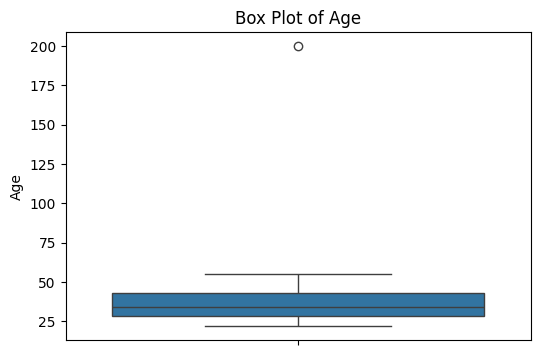


DataFrame after removing Age outlier:
       CustomerID        Age  Annual_Income_k  Purchase_Frequency  \
count   19.000000  19.000000        19.000000           19.000000   
mean   110.000000  35.105263        80.526316            4.631579   
std      5.627314   9.515454        22.911347            1.738790   
min    101.000000  22.000000        45.000000            2.000000   
25%    105.500000  28.500000        61.000000            3.000000   
50%    110.000000  33.000000        80.000000            5.000000   
75%    114.500000  41.000000        96.500000            6.000000   
max    119.000000  55.000000       120.000000            8.000000   

       Last_Purchase_Days_Ago  
count               19.000000  
mean                 9.894737  
std                  6.471259  
min                  1.000000  
25%                  5.000000  
50%                  9.000000  
75%                 13.500000  
max                 25.000000  

--- Data Distribution Visualization (Histograms) -

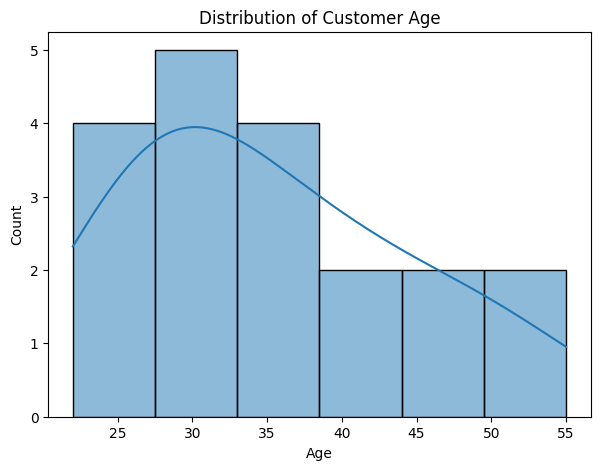

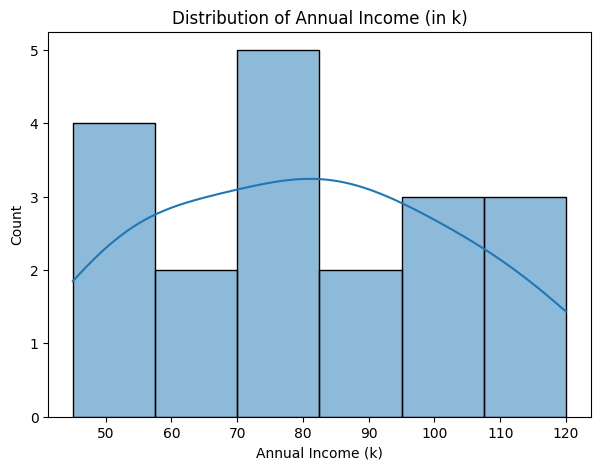


--- Relationship Visualization (Scatter Plots) ---


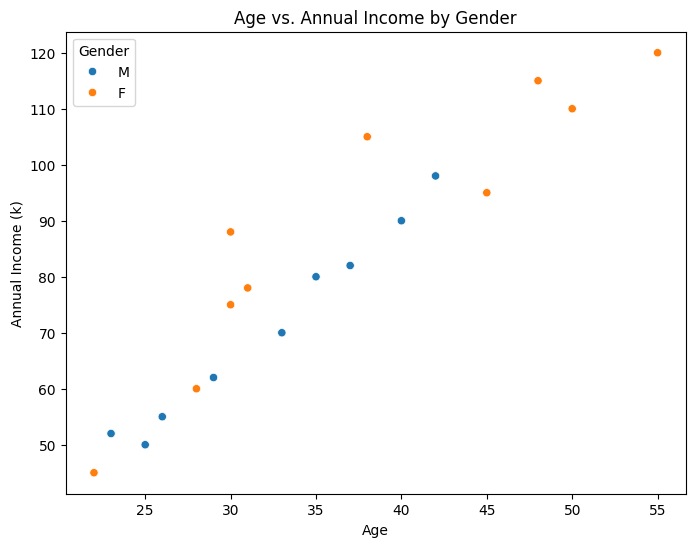


--- Categorical Data Analysis (Bar Charts) ---


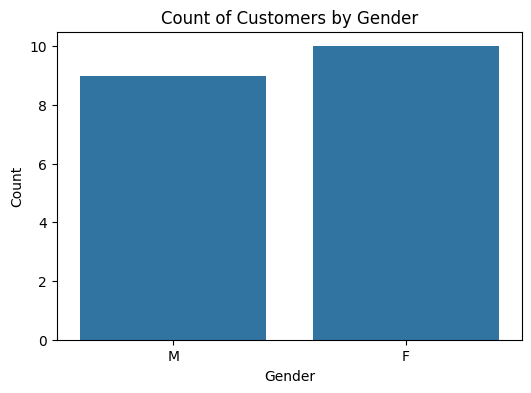


--- Correlation Analysis (Heatmap) ---


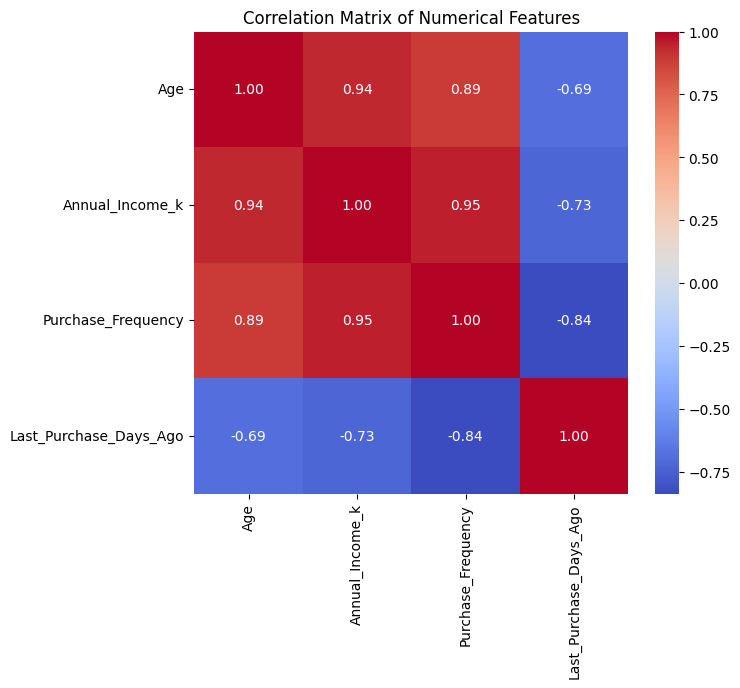


Insights from EDA:
- We found an outlier in 'Age' which was removed.
- 'Age' and 'Annual_Income_k' show a relatively normal distribution (visual from histograms).
- There appears to be a slight positive correlation between 'Age' and 'Annual_Income_k', and a negative correlation between 'Purchase_Frequency' and 'Last_Purchase_Days_Ago' (customers who buy more frequently tend to have fewer days since their last purchase, which makes sense!).
- Gender distribution is roughly even.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # For basic plotting
import seaborn as sns # For enhanced plotting

# For illustrative purposes, let's create a slightly larger dummy dataset
# Imagine this is customer data for an e-commerce site
customer_data = {
    'CustomerID': range(101, 121),
    'Age': [25, 30, 35, 28, 40, 22, 50, 33, 45, 29, 30, 26, 38, 42, 55, 23, 31, 37, 48, 200], # 200 is an outlier
    'Gender': ['M', 'F', 'M', 'F', 'M', 'F', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M', 'F', 'M'],
    'Annual_Income_k': [50, 75, 80, 60, 90, 45, 110, 70, 95, 62, 88, 55, 105, 98, 120, 52, 78, 82, 115, 40],
    'Purchase_Frequency': [3, 5, 4, 3, 6, 2, 7, 4, 5, 3, 6, 3, 6, 5, 8, 2, 4, 5, 7, 2],
    'Last_Purchase_Days_Ago': [10, 5, 15, 8, 3, 20, 2, 12, 6, 18, 4, 11, 7, 9, 1, 25, 14, 13, 5, 22]
}
df_customers = pd.DataFrame(customer_data)

print("--- Initial Look at Data (df.head(), df.info(), df.describe()) ---")
print(f"First 5 rows:\n{df_customers.head()}")
print(f"\nDataFrame Info:")
df_customers.info()
print(f"\nDescriptive Statistics:\n{df_customers.describe()}")

print("\n--- Identifying and Handling Outliers (e.g., in Age) ---")
# Box plot for Age to visualize outliers
plt.figure(figsize=(6, 4))
sns.boxplot(y=df_customers['Age'])
plt.title('Box Plot of Age')
plt.ylabel('Age')
plt.show()

# Based on box plot, 200 is clearly an outlier. Let's filter it out for better analysis.
df_customers_cleaned = df_customers[df_customers['Age'] < 100].copy() # Keep ages less than 100
print(f"\nDataFrame after removing Age outlier:\n{df_customers_cleaned.describe()}")

print("\n--- Data Distribution Visualization (Histograms) ---")
# Histogram for Age
plt.figure(figsize=(7, 5))
sns.histplot(df_customers_cleaned['Age'], kde=True) # kde=True adds a density curve
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Histogram for Annual_Income_k
plt.figure(figsize=(7, 5))
sns.histplot(df_customers_cleaned['Annual_Income_k'], kde=True)
plt.title('Distribution of Annual Income (in k)')
plt.xlabel('Annual Income (k)')
plt.ylabel('Count')
plt.show()

print("\n--- Relationship Visualization (Scatter Plots) ---")
# Scatter plot between Age and Annual_Income_k
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Age', y='Annual_Income_k', hue='Gender', data=df_customers_cleaned)
plt.title('Age vs. Annual Income by Gender')
plt.xlabel('Age')
plt.ylabel('Annual Income (k)')
plt.show()

print("\n--- Categorical Data Analysis (Bar Charts) ---")
# Count of each Gender
plt.figure(figsize=(6, 4))
sns.countplot(x='Gender', data=df_customers_cleaned)
plt.title('Count of Customers by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

print("\n--- Correlation Analysis (Heatmap) ---")
# Select only numerical columns for correlation calculation
numerical_df = df_customers_cleaned[['Age', 'Annual_Income_k', 'Purchase_Frequency', 'Last_Purchase_Days_Ago']]
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(7, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

print("\nInsights from EDA:")
print("- We found an outlier in 'Age' which was removed.")
print("- 'Age' and 'Annual_Income_k' show a relatively normal distribution (visual from histograms).")
print("- There appears to be a slight positive correlation between 'Age' and 'Annual_Income_k', and a negative correlation between 'Purchase_Frequency' and 'Last_Purchase_Days_Ago' (customers who buy more frequently tend to have fewer days since their last purchase, which makes sense!).")
print("- Gender distribution is roughly even.")



## Conclusion

 Congratulations on completing this foundational journey into Data Science! You've covered a wide array of essential topics:
 * **Descriptive Statistics:** Summarizing data with Mean, Median, Mode, Range, IQR, Variance, and Standard Deviation.
 * **Data Types:** Understanding the nature of your data (quantitative vs. qualitative).
 * **Data Handling:** Concepts of extraction, management, and the crucial steps of data wrangling.
 * **Key Python Libraries:** Hands-on experience with NumPy for numerical operations, Pandas for robust data manipulation, and SciPy for scientific computations.
 * **Probability Basics:** Grasping PMF, PDF, and Conditional Probability as the underpinnings of many ML models.
 * **Machine Learning Models:** A clear overview of what ML models are and their different types (Supervised and Unsupervised).
 * **Exploratory Data Analysis (EDA):** Learning how to visually and statistically explore data to uncover insights and prepare it for modeling.

 This notebook has equipped you with the fundamental knowledge and practical skills to confidently approach data-driven challenges. Remember, data science is an iterative process of learning, experimenting, and refining.

 ### Next Steps for Your Career Growth:

 1.  **Practice Consistently:** Apply these concepts to various datasets. Websites like Kaggle offer free datasets and competitions.
 2.  **Deepen Python Skills:** Continue learning more advanced Python programming, especially for data structures and functions.
 3.  **Explore Specific ML Algorithms:** Pick a few models from the Supervised/Unsupervised categories and learn them in more detail (e.g., how to build a Linear Regression model in Python).
 4.  **Practice EDA on New Data:** Always start with EDA when you get a new dataset.
 5.  **Stay Curious:** The field of data science is always evolving. Keep reading, learning, and asking questions!
